In [1]:
# Reproducible, Colab-safe setup
import importlib.util, subprocess, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

required = {"mlxtend": "mlxtend", "wordcloud": "wordcloud", "psutil": "psutil"}
missing = [pkg for pkg, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
OUTPUT_DIR = Path("Output_Screenshots")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_table_image(frame, filename, title, max_rows=12):
    shown = frame.head(max_rows).copy()
    fig_h = max(2.6, 0.38 * (len(shown) + 2))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    table = ax.table(cellText=shown.values, colLabels=shown.columns,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1f4e79")
            cell.set_text_props(color="white", weight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

Dataset shape: (950, 10) 
Placement distribution:
 Placed
1    873
0     77
Name: count, dtype: int64


,CGPA,Attendance,Backlogs,Aptitude_Score,Technical_Score,Communication_Score,Internship_Experience,Projects,Coding_Skill,Placed
0,7.504717,57.318439,1,59.037750,59.580081,94.672349,1,0,46.324498,1
1,6.160016,83.421223,1,65.843085,60.434548,54.608793,0,0,81.824797,0
2,7.950451,83.730352,2,60.779450,94.077042,60.419744,1,5,85.002097,1
3,8.140565,64.050855,4,61.297643,55.573903,50.761286,2,3,67.349492,1
4,5.248965,69.454775,0,72.319871,56.118894,69.037685,1,2,37.105204,0


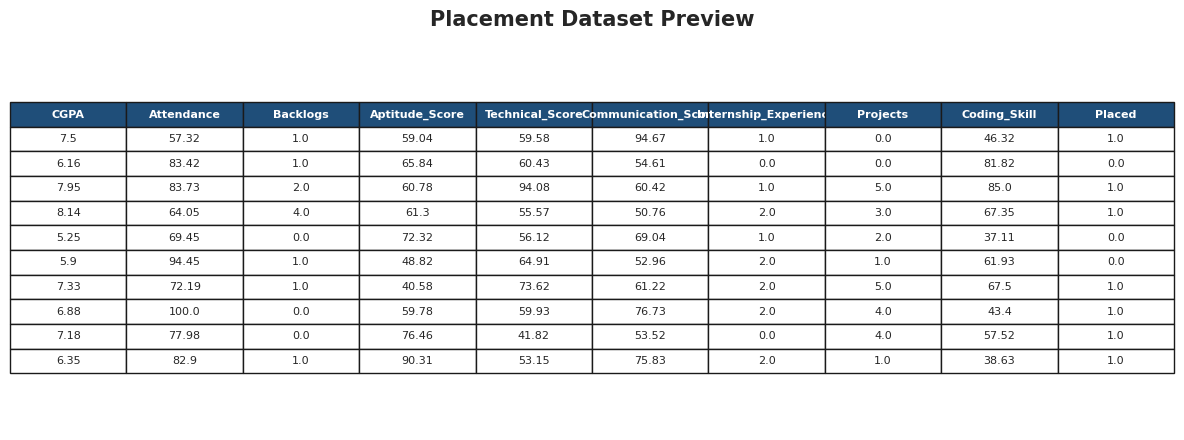

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

n=950
df=pd.DataFrame({"CGPA":np.clip(rng.normal(7.2,1.0,n),4,10),"Attendance":np.clip(rng.normal(78,12,n),35,100),
 "Backlogs":rng.poisson(.55,n),"Aptitude_Score":np.clip(rng.normal(65,15,n),15,100),
 "Technical_Score":np.clip(rng.normal(67,16,n),10,100),"Communication_Score":np.clip(rng.normal(64,15,n),10,100),
 "Internship_Experience":rng.integers(0,3,n),"Projects":rng.integers(0,7,n),"Coding_Skill":np.clip(rng.normal(64,18,n),5,100)})
z=-11+1.0*df.CGPA+.018*df.Attendance-.75*df.Backlogs+.018*df.Aptitude_Score+.026*df.Technical_Score+.015*df.Communication_Score+.48*df.Internship_Experience+.25*df.Projects+.018*df.Coding_Skill+rng.normal(0,.9,n)
prob=1/(1+np.exp(-z)); df["Placed"]=(rng.random(n)<prob).astype(int)
df.loc[rng.choice(n,15,replace=False),"Technical_Score"]=np.nan
print("Dataset shape:",df.shape,"\nPlacement distribution:\n",df.Placed.value_counts())
display(df.head()); save_table_image(df.head(10).round(2),"01_dataset_preview.png","Placement Dataset Preview")

In [3]:
X,y=df.drop(columns="Placed"),df.Placed
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,stratify=y,random_state=SEED)
models={"Logistic Regression":Pipeline([("impute",SimpleImputer(strategy="median")),("scale",StandardScaler()),("model",LogisticRegression(max_iter=1000,class_weight="balanced",random_state=SEED))]),
        "Random Forest":Pipeline([("impute",SimpleImputer(strategy="median")),("model",RandomForestClassifier(n_estimators=300,max_depth=9,class_weight="balanced",random_state=SEED))])}
rows=[]; fitted={}
for name,m in models.items():
    m.fit(X_train,y_train); p=m.predict(X_test); fitted[name]=m
    rows.append([name,accuracy_score(y_test,p),precision_score(y_test,p),recall_score(y_test,p),f1_score(y_test,p)])
scores=pd.DataFrame(rows,columns=["Model","Accuracy","Precision","Recall","F1"])
best_name=scores.sort_values("F1",ascending=False).iloc[0].Model; best=fitted[best_name]; pred=best.predict(X_test)
display(scores.round(3)); print("Best model by F1-score:",best_name)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.735,0.953,0.749,0.839
1,Random Forest,0.912,0.923,0.986,0.954


Best model by F1-score: Random Forest


Example placement probability: 93.9%
Suggestions:
- Strengthen CGPA through consistent coursework.
- Practice core technical concepts and mock interviews.
- Solve coding problems and publish project work.


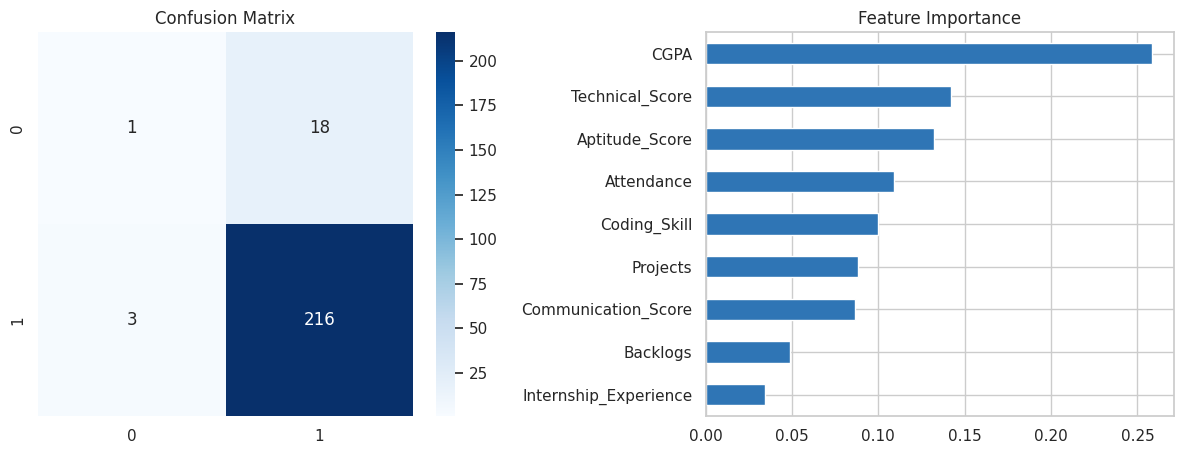

744

In [4]:
est=best.named_steps["model"]; importance=est.feature_importances_ if hasattr(est,"feature_importances_") else np.abs(est.coef_[0])
imp=pd.Series(importance,index=X.columns).sort_values(ascending=False)
sample=pd.DataFrame([{"CGPA":7.1,"Attendance":80,"Backlogs":0,"Aptitude_Score":72,"Technical_Score":68,
                      "Communication_Score":65,"Internship_Experience":1,"Projects":3,"Coding_Skill":70}])
placement_prob=float(best.predict_proba(sample)[0,1])
suggestions=[]
if sample.CGPA.iloc[0]<7.5:suggestions.append("Strengthen CGPA through consistent coursework.")
if sample.Technical_Score.iloc[0]<75:suggestions.append("Practice core technical concepts and mock interviews.")
if sample.Coding_Skill.iloc[0]<75:suggestions.append("Solve coding problems and publish project work.")
if sample.Internship_Experience.iloc[0]<1:suggestions.append("Seek an internship or industry project.")
print(f"Example placement probability: {placement_prob:.1%}"); print("Suggestions:",*suggestions,sep="\n- ")
fig,axes=plt.subplots(1,2,figsize=(12,4.7))
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt="d",cmap="Blues",ax=axes[0]); axes[0].set_title("Confusion Matrix")
imp.head(9).sort_values().plot.barh(ax=axes[1],color="#2f75b5"); axes[1].set_title("Feature Importance")
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"02_results.png",dpi=180,bbox_inches="tight"); plt.show()
metrics={"rows":len(df),"columns":len(df.columns),"class_distribution":df.Placed.value_counts().to_dict(),
         "scores":scores.round(4).to_dict("records"),"best_model":best_name,"example_probability":round(placement_prob,4),"suggestions":suggestions,
         "fairness_note":"No caste, religion, gender, or other protected attribute is used."}
Path("results.json").write_text(json.dumps(metrics,indent=2))